In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append("../Handlers")
import preprocessing
from data_visualization import DataVisualization

[nltk_data] Downloading package punkt to E:/nltk...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# ling = pd.read_csv("./Ling.csv")
# enron = pd.read_csv("./merged_enron.csv")
# spamassassin = pd.read_csv("./SpamAssassin.csv")

In [3]:
# ling["label"].value_counts()

In [4]:
# spamassassin["Is_spam"].value_counts()

In [5]:
# enron["Label"].value_counts()

In [6]:
# ling = ling.rename(columns={"subject": "Subject", "label": "Label", "body": "Body"})
# spamassassin = spamassassin.rename(columns={"Is_spam": "Label"})

In [7]:
# mixed_subject = pd.concat([
#     ling["Subject"],
#     spamassassin["Subject"],
#     enron["Subject"]
# ])

# mixed_body = pd.concat([
#     ling["Body"],
#     spamassassin["Body"],
#     enron["Body"]
# ])

# mixed_label = pd.concat([
#     ling["Label"],
#     spamassassin["Label"],
#     enron["Label"]
# ])

In [8]:
# mixed_text = pd.DataFrame({
#     "Subject": mixed_subject,
#     "Body": mixed_body,
#     "Label": mixed_label
# })
# mixed_text.to_csv("./mixed_dataset.csv")

In [9]:
mixed = pd.read_csv("./mixed_dataset.csv")
counts = mixed["Label"].value_counts()
counts

0    23148
1    19526
Name: Label, dtype: int64

In [10]:
mixed

,Unnamed: 0,Subject,Body,Label
0,0,job posting - apple-iss research center,content - length : 3386 apple-iss research cen...,0
1,1,NaN,"lang classification grimes , joseph e . and ba...",0
2,2,query : letter frequencies for text identifica...,i am posting this inquiry for sergei atamas ( ...,0
3,3,risk,a colleague and i are researching the differin...,0
4,4,request book information,earlier this morning i was on the phone with a...,0
...,...,...,...,...
42669,33710,= ? iso - 8859 - 1 ? q ? good _ news _ c = ed...,"hello , welcome to gigapharm onlinne shop .\n\...",1
42670,33711,all prescript medicines are on special . to b...,i got it earlier than expected and it was wrap...,1
42671,33712,the next generation online pharmacy .\n,are you ready to rock on ? let the man in you ...,1
42672,33713,bloow in 5 - 10 times the time\n,learn how to last 5 - 10 times longer in\n\nbe...,1


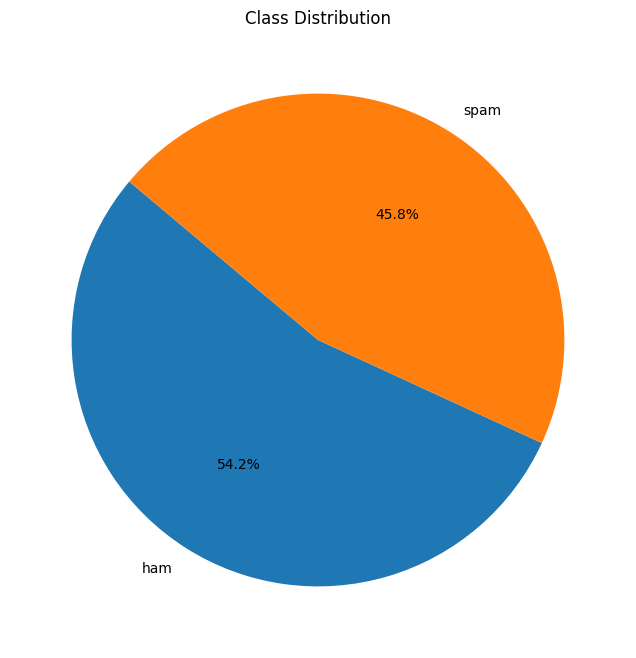

In [11]:
dv = DataVisualization()
dv.visualize_class_distribution(counts, type="pie", save=False)

In [12]:
subject = "Subject"
body = "Body"
inp = mixed.apply(lambda x: f'{x[subject]} {x[body]}', axis=1)

In [15]:
from functools import partial

preprocess_text = partial(
    preprocessing.preprocess_text,
    remove_numbers=True
)

preprocessed_data = inp.apply(preprocess_text)
print(preprocessed_data)


0        [job, posting, appleiss, research, center, con...
1        [nan, lang, classification, grimes, joseph, e,...
2        [query, letter, frequencies, text, identificat...
3        [risk, colleague, researching, differing, degr...
4        [request, book, information, earlier, morning,...
                               ...                        
42669    [iso, q, good, news, c, edaliss, val, edumm, v...
42670    [prescript, medicines, special, precise, put, ...
42671    [next, generation, online, pharmacy, ready, ro...
42672    [bloow, times, time, learn, last, times, longe...
42673    [dear, sir, interested, hi, need, softwares, g...
Length: 42674, dtype: object


In [16]:
inp_lemmatizing = preprocessed_data.apply(preprocessing.lemmatizing)
inp_lemmatizing

0        job posting appleiss research center content l...
1        nan lang classification grime joseph e barbara...
2        query letter frequency text identification pos...
3        risk colleague researching differing degree ri...
4        request book information earlier morning phone...
                               ...                        
42669    iso q good news c edaliss val edumm vl eoggra ...
42670    prescript medicine special precise put buck ba...
42671    next generation online pharmacy ready rock let...
42672    bloow time time learn last time longer bed rea...
42673    dear sir interested hi need software give link...
Length: 42674, dtype: object

In [17]:
inp_lemmatizing_tfidf = preprocessing.vectorizing(inp_lemmatizing, "tfidf", min_df=4)
del inp_lemmatizing

Begin LinearSVC
Skipping training and validation accuracy calculation.
LinearSVC classification report
Model does not support probability prediction. Skipping ROC curve plotting.
{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'LinearSVC', 'metrics': {'accuracy': 0.9884007029876977, 'weighted_precision': 0.9884264469758958, 'wighted_recall': 0.9884007029876977, 'weighted_f1': 0.9884036275983547, 'macro_precision': 0.9880912983887999, 'macro_recall': 0.988583814996945, 'macro_f1': 0.9883274794023627, 'roc_auc': 0.9885838149969449}, 'confusion_matrix': array([[4556,   63],
       [  36, 3880]], dtype=int64), 'epochs': 10}


Begin MultinomialNB
Skipping training and validation accuracy calculation.
MultinomialNB classification report


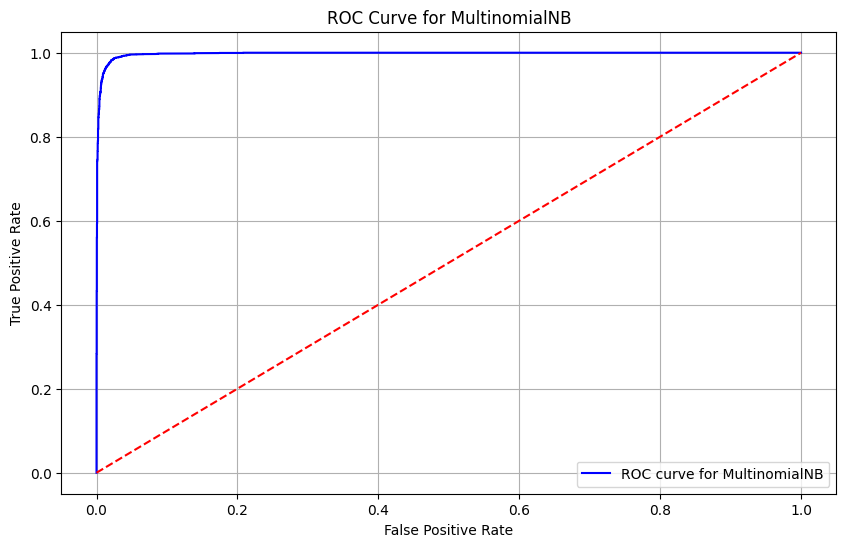

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'MultinomialNB', 'metrics': {'accuracy': 0.9784417106033978, 'weighted_precision': 0.9784439139294187, 'wighted_recall': 0.9784417106033978, 'weighted_f1': 0.9784374003462625, 'macro_precision': 0.9784826373842341, 'macro_recall': 0.9781001264705602, 'macro_f1': 0.9782858948079611, 'roc_auc': 0.9781001264705603}, 'confusion_matrix': array([[4537,   82],
       [ 102, 3814]], dtype=int64), 'epochs': 10}


Begin BernoulliNB
Skipping training and validation accuracy calculation.
BernoulliNB classification report


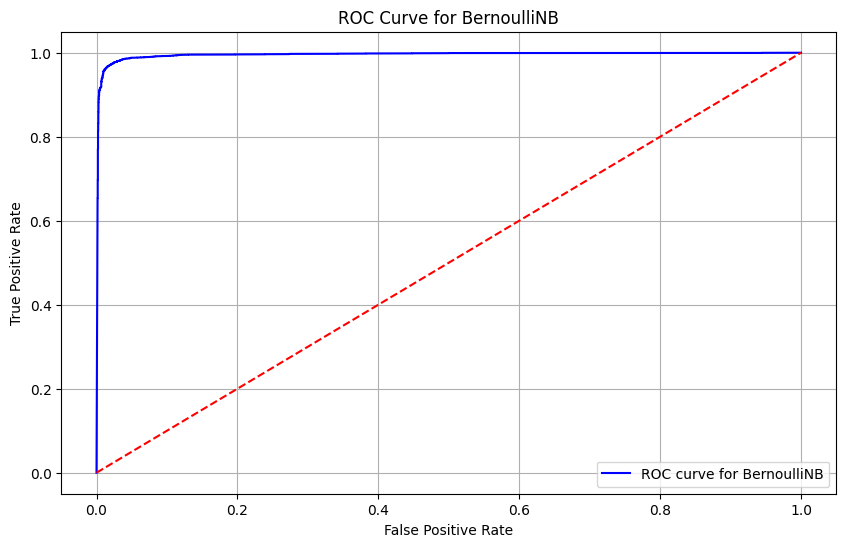

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'BernoulliNB', 'metrics': {'accuracy': 0.9669595782073813, 'weighted_precision': 0.9679872261233062, 'wighted_recall': 0.9669595782073813, 'weighted_f1': 0.9670036527398067, 'macro_precision': 0.9660658524932658, 'macro_recall': 0.9685605719680292, 'macro_f1': 0.9668388421212164, 'roc_auc': 0.9685605719680292}, 'confusion_matrix': array([[4384,  235],
       [  47, 3869]], dtype=int64), 'epochs': 10}


Begin RandomForestClassifier
Skipping training and validation accuracy calculation.
RandomForestClassifier classification report


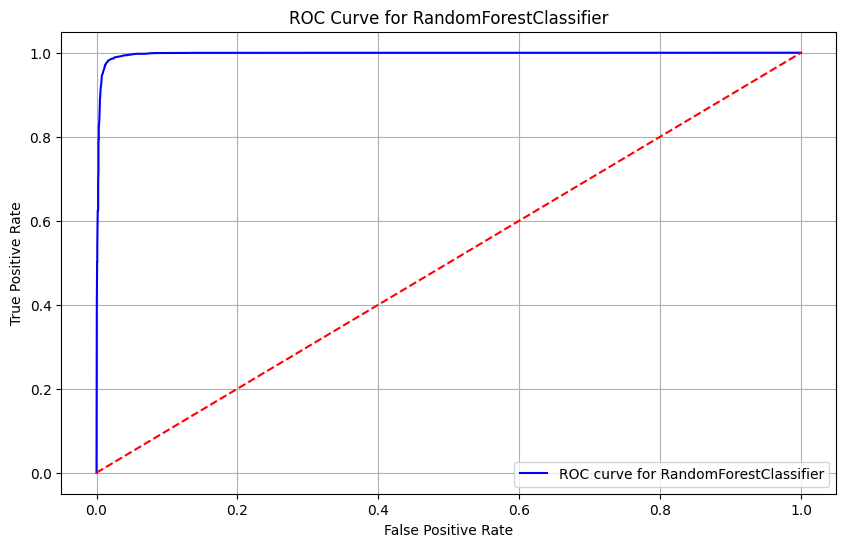

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'RandomForestClassifier', 'metrics': {'accuracy': 0.9820738137082601, 'weighted_precision': 0.9820850292454175, 'wighted_recall': 0.9820738137082601, 'weighted_f1': 0.9820763698900782, 'macro_precision': 0.9818222118246971, 'macro_recall': 0.9820971125393383, 'macro_f1': 0.981956570168873, 'roc_auc': 0.9820971125393383}, 'confusion_matrix': array([[4535,   84],
       [  69, 3847]], dtype=int64), 'epochs': 10}


Begin DecisionTreeClassifier
Skipping training and validation accuracy calculation.
DecisionTreeClassifier classification report


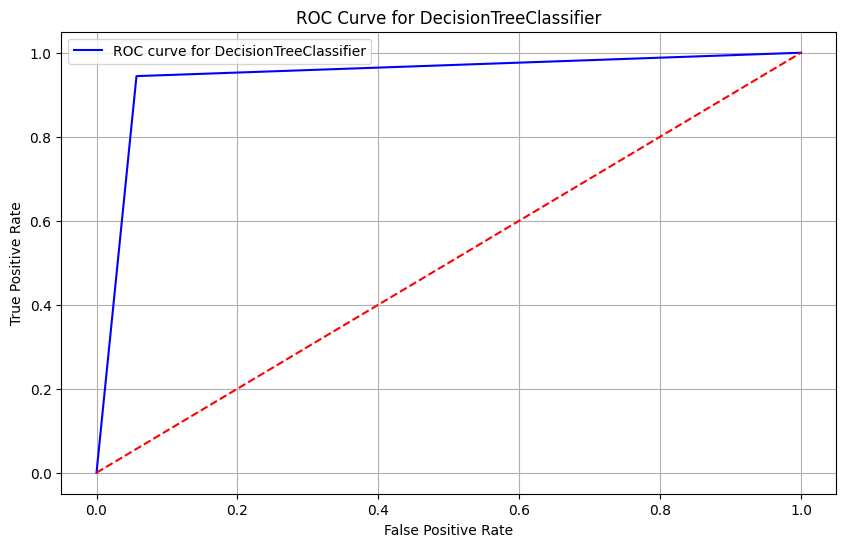

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'DecisionTreeClassifier', 'metrics': {'accuracy': 0.9434094903339192, 'weighted_precision': 0.9435151480637582, 'wighted_recall': 0.9434094903339192, 'weighted_f1': 0.9434335844742814, 'macro_precision': 0.9427249631267705, 'macro_recall': 0.9434796122336108, 'macro_f1': 0.943073197651416, 'roc_auc': 0.9434796122336107}, 'confusion_matrix': array([[4354,  265],
       [ 218, 3698]], dtype=int64), 'epochs': 10}


Begin AdaBoostClassifier
Skipping training and validation accuracy calculation.
AdaBoostClassifier classification report


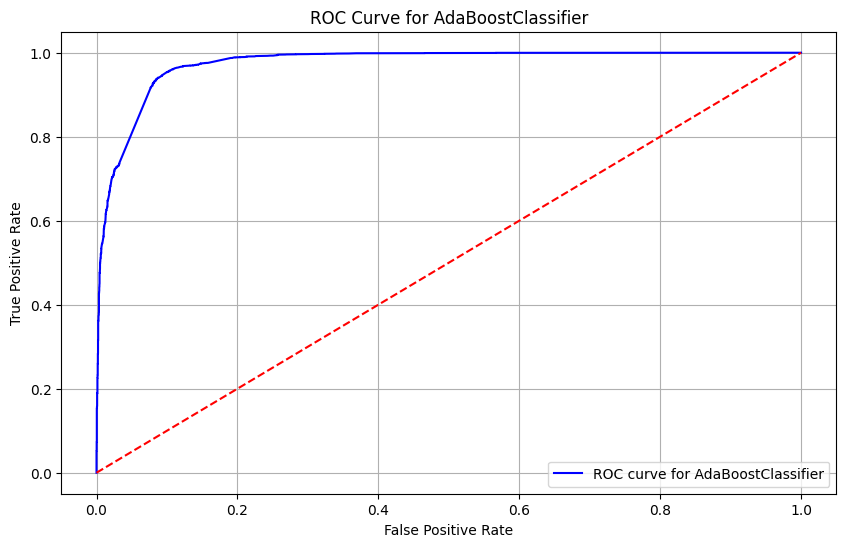

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'AdaBoostClassifier', 'metrics': {'accuracy': 0.9250146455770357, 'weighted_precision': 0.926013343079482, 'wighted_recall': 0.9250146455770357, 'weighted_f1': 0.925111205084203, 'macro_precision': 0.9240411960451568, 'macro_recall': 0.9262319656718343, 'macro_f1': 0.9247298492778067, 'roc_auc': 0.9262319656718343}, 'confusion_matrix': array([[4210,  409],
       [ 231, 3685]], dtype=int64), 'epochs': 10}


Begin LogisticRegression
Skipping training and validation accuracy calculation.
LogisticRegression classification report


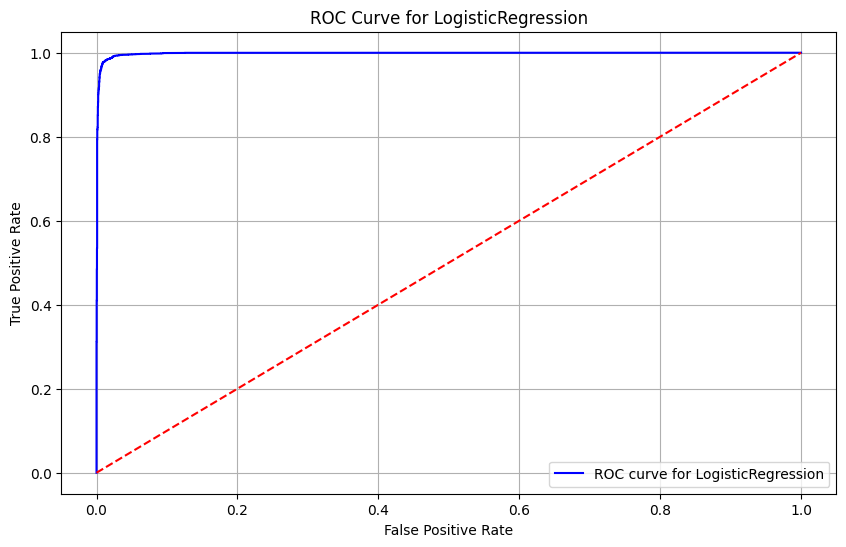

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'LogisticRegression', 'metrics': {'accuracy': 0.9832454598711189, 'weighted_precision': 0.9833036318379974, 'wighted_recall': 0.9832454598711189, 'weighted_f1': 0.9832517402800173, 'macro_precision': 0.982804913634149, 'macro_recall': 0.983529387764399, 'macro_f1': 0.9831440542445177, 'roc_auc': 0.983529387764399}, 'confusion_matrix': array([[4527,   92],
       [  51, 3865]], dtype=int64), 'epochs': 10}


Begin SGDClassifier
Skipping training and validation accuracy calculation.
SGDClassifier classification report
Model does not support probability prediction. Skipping ROC curve plotting.
{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'SGDClassifier', 'metrics': {'accuracy': 0.9845342706502637, 'weighted_precision': 0.9846046605380238, 'wighted_recall': 0.9845342706502637, 'weighted_f1': 0.9845407252247184, 'macro_precision': 0.9840667899826396, 'macro_recall': 0.9848755838399859, 'macro_f1': 0.9844420824890282, 'roc_auc': 0.984

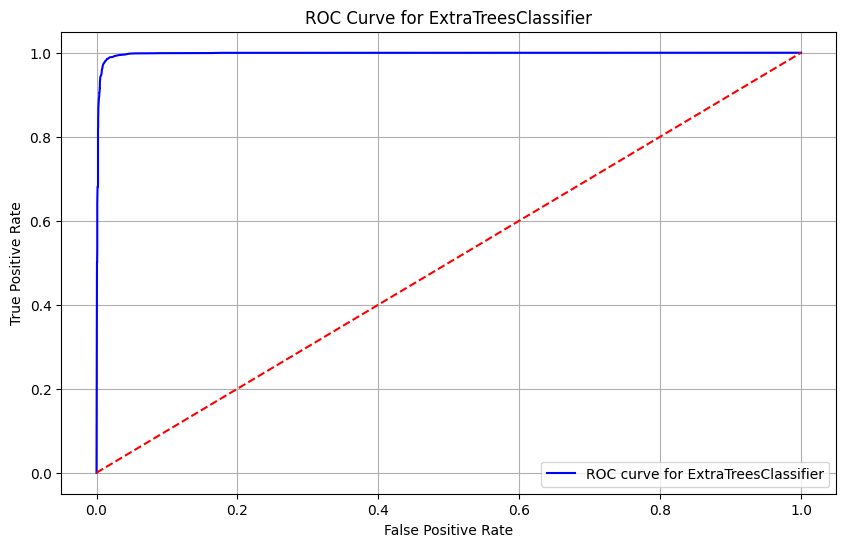

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'ExtraTreesClassifier', 'metrics': {'accuracy': 0.983128295254833, 'weighted_precision': 0.9831579652447221, 'wighted_recall': 0.983128295254833, 'weighted_f1': 0.9831213593286938, 'macro_precision': 0.9834186902808706, 'macro_recall': 0.982624395704468, 'macro_f1': 0.9829994604267984, 'roc_auc': 0.982624395704468}, 'confusion_matrix': array([[4567,   52],
       [  92, 3824]], dtype=int64), 'epochs': 10}


Begin XGBClassifier
Skipping training and validation accuracy calculation.
XGBClassifier classification report


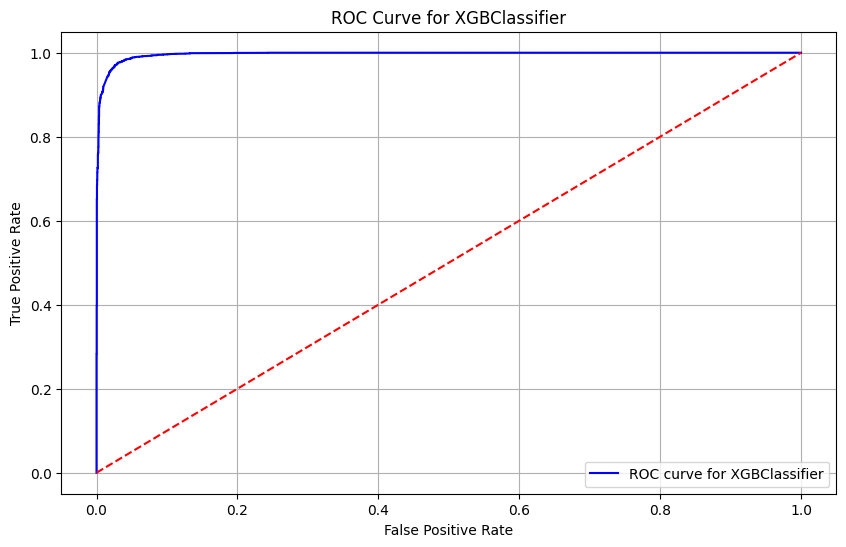

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'XGBClassifier', 'metrics': {'accuracy': 0.970240187463386, 'weighted_precision': 0.9706959007153562, 'wighted_recall': 0.970240187463386, 'weighted_f1': 0.9702692796423873, 'macro_precision': 0.9693829236000491, 'macro_recall': 0.9712223084426562, 'macro_f1': 0.9701016419224053, 'roc_auc': 0.9712223084426562}, 'confusion_matrix': array([[4431,  188],
       [  66, 3850]], dtype=int64), 'epochs': 10}


Begin KNeighborsClassifier
Skipping training and validation accuracy calculation.
KNeighborsClassifier classification report


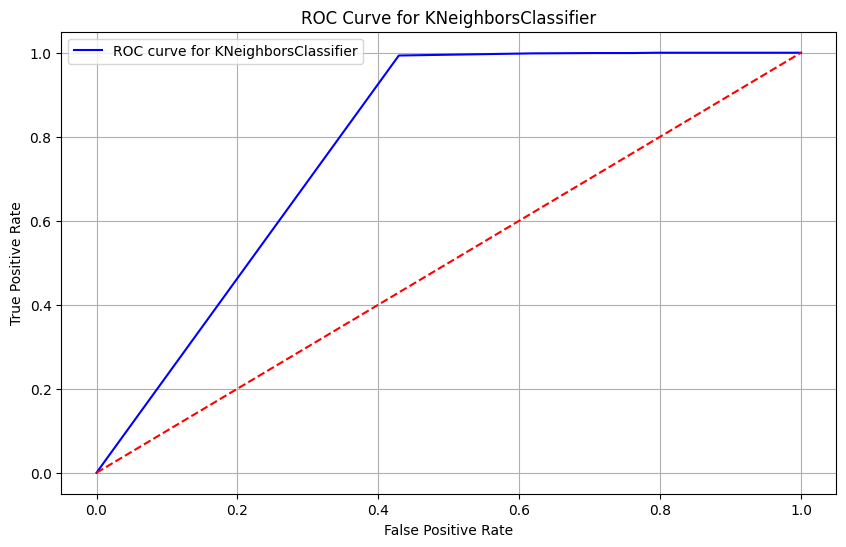

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'KNeighborsClassifier', 'metrics': {'accuracy': 0.6167545401288811, 'weighted_precision': 0.7899981420445757, 'wighted_recall': 0.6167545401288811, 'weighted_f1': 0.5683884223721922, 'macro_precision': 0.7713472611645247, 'macro_recall': 0.6458607317866581, 'macro_f1': 0.5788023215400183, 'roc_auc': 0.6458607317866581}, 'confusion_matrix': array([[1351, 3268],
       [   3, 3913]], dtype=int64), 'epochs': 10}


Begin BaggingClassifier
Skipping training and validation accuracy calculation.
BaggingClassifier classification report


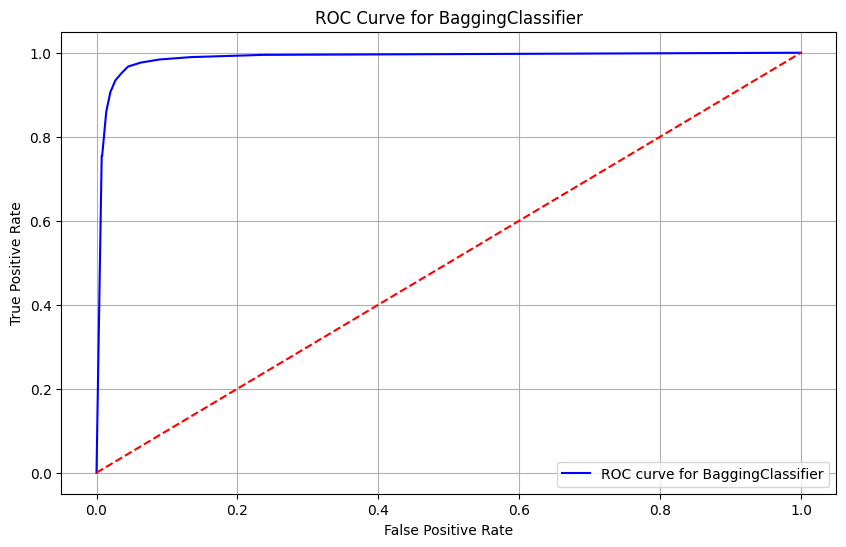

{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'BaggingClassifier', 'metrics': {'accuracy': 0.9586408904510838, 'weighted_precision': 0.9586347686351697, 'wighted_recall': 0.9586408904510838, 'weighted_f1': 0.9586330457953267, 'macro_precision': 0.9585215150407601, 'macro_recall': 0.9581737708594049, 'macro_f1': 0.9583427935323168, 'roc_auc': 0.9581737708594049}, 'confusion_matrix': array([[4452,  167],
       [ 186, 3730]], dtype=int64), 'epochs': 10}


Begin VotingClassifier
Skipping training and validation accuracy calculation.
VotingClassifier classification report
Model does not support probability prediction. Skipping ROC curve plotting.
{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'VotingClassifier', 'metrics': {'accuracy': 0.9886350322202695, 'weighted_precision': 0.9886465864052628, 'wighted_recall': 0.9886350322202695, 'weighted_f1': 0.9886368634755702, 'macro_precision': 0.9884076866390794, 'macro_recall': 0.988722580998987, 'macro_f1': 0.9885611356828415, 'roc_a

In [18]:
from traintest import ClassificationModel2, add_to_json_array

clsml2 = ClassificationModel2(inp_lemmatizing_tfidf, mixed["Label"], "mixed_text_lemmatized_tfidf")
clsml2.split(test_size=0.2, valid_size=0)

metric_results = clsml2.train_and_evaluate_models(
    valid_size=0,
    threading=False,
    nomlp=True,
    save_plot=True
)

del inp_lemmatizing_tfidf

In [19]:
print(metric_results)

def convert(dic):
    dic["confusion_matrix"] = dic["confusion_matrix"].tolist()
    return dic

metric_results = list(map(convert, metric_results))

add_to_json_array("./mixed_text_classification_report.json", metric_results, mode="overwrite")

[{'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'LinearSVC', 'metrics': {'accuracy': 0.9884007029876977, 'weighted_precision': 0.9884264469758958, 'wighted_recall': 0.9884007029876977, 'weighted_f1': 0.9884036275983547, 'macro_precision': 0.9880912983887999, 'macro_recall': 0.988583814996945, 'macro_f1': 0.9883274794023627, 'roc_auc': 0.9885838149969449}, 'confusion_matrix': array([[4556,   63],
       [  36, 3880]], dtype=int64), 'epochs': 10}, {'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'MultinomialNB', 'metrics': {'accuracy': 0.9784417106033978, 'weighted_precision': 0.9784439139294187, 'wighted_recall': 0.9784417106033978, 'weighted_f1': 0.9784374003462625, 'macro_precision': 0.9784826373842341, 'macro_recall': 0.9781001264705602, 'macro_f1': 0.9782858948079611, 'roc_auc': 0.9781001264705603}, 'confusion_matrix': array([[4537,   82],
       [ 102, 3814]], dtype=int64), 'epochs': 10}, {'dataset': 'mixed_text_lemmatized_tfidf', 'model': 'BernoulliNB', 'metrics': {'accura